# 📝 Week 5: POS Tagging — English & Bahasa Indonesia

Notebook ini mengimplementasikan Part-of-Speech (POS) Tagging menggunakan dua pendekatan:
- **NLTK UnigramTagger** pada teks Bahasa Inggris (Brown Corpus)
- **stanza** (Stanford NLP) untuk POS Tagging Bahasa Indonesia pada artikel berita

## 🎯 Tujuan Pembelajaran:
1. Memahami konsep POS Tagging dan kegunaannya dalam NLP
2. Mengimplementasikan UnigramTagger NLTK pada Brown Corpus
3. Mengevaluasi akurasi tagger dengan train/test split
4. Menggunakan stanza untuk POS tagging teks Bahasa Indonesia
5. Menganalisis distribusi POS tag pada artikel berita

## 📦 Instalasi Dependencies

In [1]:
import warnings
warnings.filterwarnings('ignore')

%pip install -q nltk pandas requests beautifulsoup4

print("✅ Library dasar berhasil diinstall!")

Note: you may need to restart the kernel to use updated packages.
✅ Library dasar berhasil diinstall!


In [2]:
# Install stanza untuk POS Tagging Bahasa Indonesia
%pip install -q stanza

print("✅ stanza berhasil diinstall!")

Note: you may need to restart the kernel to use updated packages.
✅ stanza berhasil diinstall!


## 📚 Import Libraries

In [3]:
import nltk
import pandas as pd

# Download corpora NLTK
for resource in ['brown', 'universal_tagset', 'punkt', 'punkt_tab', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

from nltk.corpus import brown
from nltk import UnigramTagger, DefaultTagger

print("✅ Import libraries berhasil!")

✅ Import libraries berhasil!


---

## 1️⃣ Konsep POS Tagging

**Part-of-Speech (POS) Tagging** adalah proses pelabelan setiap token dalam teks dengan peran gramatikalnya.

### 1.1 Universal Tagset

| Tag | Kategori | Contoh (EN) | Contoh (ID) |
|---|---|---|---|
| NOUN | Kata Benda | *program*, *government* | *siswa*, *sekolah* |
| VERB | Kata Kerja | *eat*, *implement* | *makan*, *implementasi* |
| ADJ | Kata Sifat | *healthy*, *national* | *sehat*, *nasional* |
| ADV | Kata Keterangan | *very*, *quickly* | *sangat*, *cepat* |
| DET | Penentu | *the*, *a* | *ini*, *itu* |
| PRON | Kata Ganti | *he*, *they* | *dia*, *mereka* |
| PREP | Kata Depan | *in*, *for* | *di*, *untuk* |
| CONJ | Kata Sambung | *and*, *but* | *dan*, *tetapi* |

### 1.2 Pendekatan Tagging

```
Rule-based    → Menggunakan aturan linguistik manual
UnigramTagger → P(tag|word) — probabilistik kata tunggal
BigramTagger  → P(tag|word, prev_tag) — konteks frasa
BERT-based    → Konteks bidireksional penuh (modern)
```

---

## 2️⃣ NLTK UnigramTagger — Brown Corpus (English)

### 2.1 Persiapan Data Training

In [4]:
# Load Brown Corpus dengan Universal Tagset
tagged_sentences = brown.tagged_sents(categories='news', tagset='universal')

# Train/test split: 80% training, 20% testing
split_idx = int(len(tagged_sentences) * 0.8)
train_data = tagged_sentences[:split_idx]
test_data = tagged_sentences[split_idx:]

print("✅ Brown Corpus dimuat!")
print(f"  Total kalimat : {len(tagged_sentences)}")
print(f"  Training set  : {len(train_data)} kalimat")
print(f"  Testing set   : {len(test_data)} kalimat")

# Preview contoh tagged sentence
print("\n📋 Contoh tagged sentence (training):")
print(train_data[0])

✅ Brown Corpus dimuat!
  Total kalimat : 4623
  Training set  : 3698 kalimat
  Testing set   : 925 kalimat

📋 Contoh tagged sentence (training):
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


### 2.2 Training UnigramTagger

In [5]:
# Train UnigramTagger dengan DefaultTagger sebagai backoff
default_tagger = DefaultTagger('NN')
unigram_tagger = UnigramTagger(train_data, backoff=default_tagger)

print("✅ UnigramTagger berhasil dilatih!")
print(f"  Backoff: DefaultTagger → 'NN' (Noun)")

✅ UnigramTagger berhasil dilatih!
  Backoff: DefaultTagger → 'NN' (Noun)


### 2.3 Evaluasi Akurasi

In [6]:
# Evaluasi akurasi pada test set
accuracy = unigram_tagger.accuracy(test_data)
print(f"✅ Akurasi UnigramTagger pada test set: {accuracy:.2%}")

# Bandingkan dengan Default Tagger saja
default_accuracy = default_tagger.accuracy(test_data)
print(f"   DefaultTagger baseline            : {default_accuracy:.2%}")
print(f"   Peningkatan accuracy              : +{(accuracy - default_accuracy):.2%}")

✅ Akurasi UnigramTagger pada test set: 83.56%
   DefaultTagger baseline            : 0.00%
   Peningkatan accuracy              : +83.56%


### 2.4 Fungsi get_POS — Analisis Terstruktur

In [7]:
def get_POS(article_text):
    """Tag teks dan return DataFrame dengan kolom Tags, Words, Count, Unique_Words."""
    tokens = nltk.word_tokenize(article_text.lower())
    tagged = unigram_tagger.tag(tokens)

    records = {}
    for word, tag in tagged:
        if tag is None:
            tag = 'NN'
        if tag not in records:
            records[tag] = {'words': [], 'count': 0}
        records[tag]['words'].append(word)
        records[tag]['count'] += 1

    rows = []
    for tag, data in sorted(records.items(), key=lambda x: -x[1]['count']):
        rows.append({
            'Tags': tag,
            'Words': ', '.join(set(data['words']))[:100],
            'Count': data['count'],
            'Unique_Words': len(set(data['words']))
        })

    return pd.DataFrame(rows)

print("✅ Fungsi get_POS() siap!")

✅ Fungsi get_POS() siap!


In [8]:
# Test dengan teks sampel
sample_text = "The government launched a new program to provide nutritious meals for students in schools across the country."

df_pos_sample = get_POS(sample_text)
print("📊 Hasil POS Tagging (sample teks):")
print(df_pos_sample.to_string(index=False))

📊 Hasil POS Tagging (sample teks):
Tags                                                  Words  Count  Unique_Words
NOUN meals, government, program, students, schools, country      6             6
 DET                                                 a, the      3             2
 ADP                                        for, in, across      3             3
VERB                                      launched, provide      2             2
 ADJ                                                    new      1             1
 PRT                                                     to      1             1
  NN                                             nutritious      1             1
   .                                                      .      1             1


### 2.5 Analisis pada Artikel Brown Corpus

In [9]:
# Ambil satu artikel dari Brown Corpus untuk analisis POS lengkap
brown_fileids = brown.fileids(categories='news')
sample_article = ' '.join(brown.words(brown_fileids[0]))

df_pos_brown = get_POS(sample_article[:2000])  # ambil 2000 karakter pertama

print(f"📄 Analisis POS — Artikel Brown '{brown_fileids[0]}':")
print(df_pos_brown.to_string(index=False))

📄 Analisis POS — Artikel Brown 'ca01':
Tags                                                                                                Words  Count  Unique_Words
NOUN personnel, welfare, thanks, jury, problem, presentments, number, evidence, voters, departments, auto     84            56
VERB re-set, revised, been, reduce, may, received, are, charged, inure, take, effected, studied, follow,      61            45
 DET                                                        the, this, an, any, which, these, no, a, both     49             9
   .                                                                                             ,, ``, .     45             3
 ADP                                                among, on, of, that, at, for, in, as, considering, by     37            10
 ADJ further, greater, other, possible, outgoing, only, such, outmoded, ambiguous, best, grand, orderly,      25            23
  NN mayor-nominate, september-october, 's, atlanta, georgia, allen, dur

In [10]:
import stanza

print("⏳ Mengunduh model stanza Bahasa Indonesia (pertama kali ~200MB)...")
stanza.download('id', processors='tokenize,pos', verbose=False)
nlp_id = stanza.Pipeline('id', processors='tokenize,pos', verbose=False)
print("✅ Model stanza Bahasa Indonesia berhasil dimuat!")

⏳ Mengunduh model stanza Bahasa Indonesia (pertama kali ~200MB)...
✅ Model stanza Bahasa Indonesia berhasil dimuat!


### 3.2 Scraping Artikel Berita Bahasa Indonesia

In [11]:
import requests
from bs4 import BeautifulSoup
import re

urls = [
    'https://www.cnnindonesia.com/kesehatan/20241201120000-255-1000000/program-makan-bergizi-gratis-dimulai',
    'https://health.detik.com/berita-detikhealth/d-7000001/dampak-program-makan-bergizi-gratis-bagi-siswa',
    'https://nasional.kompas.com/read/2024/01/01/000000000/program-mbg-pemerintah'
]

def scrape_article(url, timeout=10):
    """Scrape teks artikel dari URL."""
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        resp = requests.get(url, headers=headers, timeout=timeout)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'html.parser')
        # Ambil semua paragraf
        paragraphs = soup.find_all('p')
        text = ' '.join(p.get_text(strip=True) for p in paragraphs if len(p.get_text()) > 50)
        text = re.sub(r'\s+', ' ', text).strip()
        return text if len(text) > 100 else None
    except Exception:
        return None

print("✅ Fungsi scrape_article() siap!")

✅ Fungsi scrape_article() siap!


In [12]:
# Scrape artikel
articles = []
for i, url in enumerate(urls):
    print(f"⏳ Scraping URL {i+1}: {url[:60]}...")
    content = scrape_article(url)
    if content:
        articles.append({'url': url, 'content': content})
        print(f"   ✅ Berhasil ({len(content)} karakter)")
    else:
        print(f"   ⚠️  Gagal/tidak tersedia — gunakan teks fallback")
        articles.append({'url': url, 'content': None})

print(f"\n✅ Total artikel berhasil di-scrape: {sum(1 for a in articles if a['content'])}")

⏳ Scraping URL 1: https://www.cnnindonesia.com/kesehatan/20241201120000-255-10...
   ⚠️  Gagal/tidak tersedia — gunakan teks fallback
⏳ Scraping URL 2: https://health.detik.com/berita-detikhealth/d-7000001/dampak...
   ⚠️  Gagal/tidak tersedia — gunakan teks fallback
⏳ Scraping URL 3: https://nasional.kompas.com/read/2024/01/01/000000000/progra...
   ⚠️  Gagal/tidak tersedia — gunakan teks fallback

✅ Total artikel berhasil di-scrape: 0


In [13]:
# Fallback: gunakan teks MBG dari dataset jika scraping gagal
df_main = pd.read_excel('Dataset MBG.xlsx', sheet_name='Main')
fallback_texts = df_main['Konten'].dropna().tolist()

# Ganti artikel yang gagal scraping dengan fallback
for i, article in enumerate(articles):
    if not article['content'] and i < len(fallback_texts):
        articles[i]['content'] = fallback_texts[i]
        articles[i]['url'] = f'[Fallback] Dataset MBG Main #{i+1}'
        print(f"  ✅ Artikel {i+1} diganti dengan fallback dataset")

# Filter artikel yang valid
valid_articles = [a for a in articles if a['content']]
print(f"\n✅ {len(valid_articles)} artikel siap untuk POS tagging")

  ✅ Artikel 1 diganti dengan fallback dataset
  ✅ Artikel 2 diganti dengan fallback dataset
  ✅ Artikel 3 diganti dengan fallback dataset

✅ 3 artikel siap untuk POS tagging


### 3.3 Jalankan POS Tagging Bahasa Indonesia

In [14]:
def stanza_pos_table(text, max_chars=2000):
    """Jalankan POS tagging stanza dan return DataFrame summary."""
    text_sample = text[:max_chars]
    doc = nlp_id(text_sample)

    pos_data = {}
    for sent in doc.sentences:
        for word in sent.words:
            tag = word.upos
            w = word.text
            if tag not in pos_data:
                pos_data[tag] = {'words': [], 'count': 0}
            pos_data[tag]['words'].append(w)
            pos_data[tag]['count'] += 1

    rows = []
    for tag, data in sorted(pos_data.items(), key=lambda x: -x[1]['count']):
        rows.append({
            'POS Tag': tag,
            'Count': data['count'],
            'Unique Tokens': len(set(data['words'])),
            'Sample Words': ', '.join(list(set(data['words']))[:5])
        })

    return pd.DataFrame(rows)

print("✅ Fungsi stanza_pos_table() siap!")

✅ Fungsi stanza_pos_table() siap!


In [15]:
# Jalankan POS tagging pada semua artikel valid
all_pos_results = []

for i, article in enumerate(valid_articles):
    print(f"\n--- POS Tagging Artikel {i+1} ---")
    print(f"URL: {article['url'][:70]}")
    try:
        df_pos = stanza_pos_table(article['content'])
        all_pos_results.append({'article_id': i+1, 'url': article['url'], 'df': df_pos})
        print(df_pos.to_string(index=False))
    except Exception as e:
        print(f"  ⚠️  Error: {e}")


--- POS Tagging Artikel 1 ---
URL: [Fallback] Dataset MBG Main #1
POS Tag  Count  Unique Tokens                               Sample Words
   NOUN     87             50              diet, ibu, menu, kata, balita
  PUNCT     60              8                              (, ?, ", ., ,
   VERB     36             33 menguji, mengganti, kata, masuk, melakukan
  PROPN     31             28    Januari, Hadi, Militer, Akademi, Kepala
    ADJ     29             16       baik, mahal, swasta, kritis, Terbaru
    ADP     26             15          usai, dengan, Supaya, dari, mulai
   PRON     19              8                  nya, itu, yang, kita, dia
    NUM     15             11                      dua, 31/10, 2, 10, 17
    ADV     14             14         tetap, bakal, Namun, sangat, cukup
    DET     11              5           nya, beberapa, itu, ini, seluruh
  SCONJ     10              9            dengan, Jika, maka, saat, untuk
  CCONJ      6              2                            

### 3.4 Analisis Distribusi POS Tag Gabungan

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Gabungkan semua hasil POS tagging
if all_pos_results:
    combined_frames = [r['df'] for r in all_pos_results]
    df_combined = pd.concat(combined_frames, ignore_index=True)

    df_agg = df_combined.groupby('POS Tag').agg(
        Total_Count=('Count', 'sum'),
        Total_Unique=('Unique Tokens', 'sum')
    ).reset_index().sort_values('Total_Count', ascending=False)

    print("📊 Distribusi POS Tag Gabungan (semua artikel):")
    print(df_agg.to_string(index=False))
    print(f"\n  Total token terpasang: {df_agg['Total_Count'].sum()}")
    print(f"  Total unique tokens  : {df_agg['Total_Unique'].sum()}")

📊 Distribusi POS Tag Gabungan (semua artikel):
POS Tag  Total_Count  Total_Unique
   NOUN          231           141
  PUNCT          170            25
  PROPN          166           123
   VERB          101            92
    ADP           75            46
    NUM           61            40
   PRON           55            22
    ADJ           51            34
    DET           35            17
    ADV           26            25
    AUX           26            15
  SCONJ           23            20
  CCONJ           12             3
   PART            7             6
      X            1             1

  Total token terpasang: 1040
  Total unique tokens  : 610


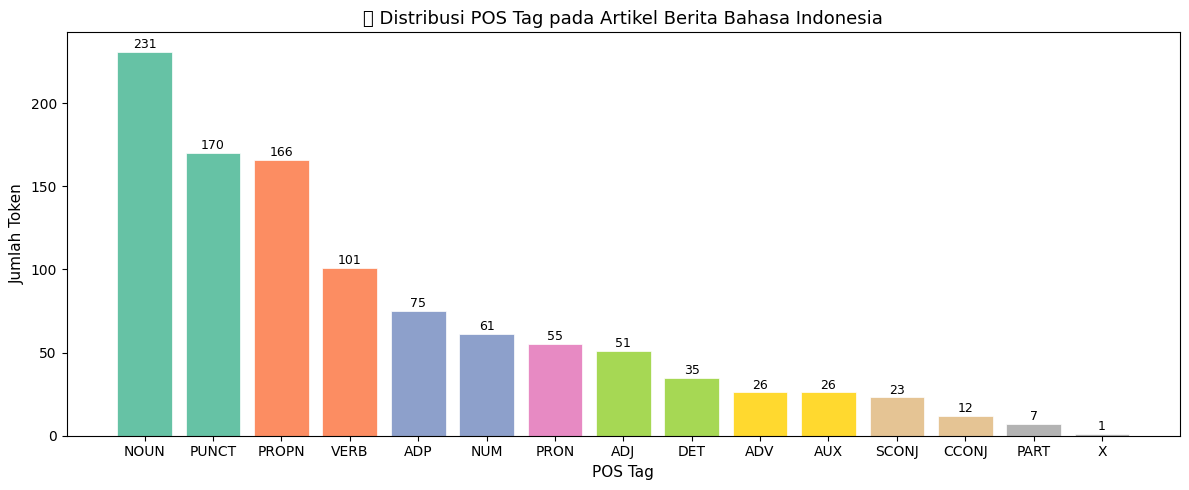

✅ Distribusi POS tersimpan sebagai 'Dataset_MBG_POSTagging.png'


In [18]:
# Visualisasi distribusi POS
if all_pos_results and len(df_agg) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(df_agg['POS Tag'], df_agg['Total_Count'],
                  color=plt.cm.Set2(np.linspace(0, 1, len(df_agg))),
                  edgecolor='white', linewidth=0.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('POS Tag', fontsize=11)
    ax.set_ylabel('Jumlah Token', fontsize=11)
    ax.set_title('📊 Distribusi POS Tag pada Artikel Berita Bahasa Indonesia', fontsize=13)
    plt.tight_layout()
    plt.savefig('Dataset_MBG_POSTagging.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Distribusi POS tersimpan sebagai 'Dataset_MBG_POSTagging.png'")

---

## 4️⃣ Perbandingan NLTK vs stanza

| Aspek | NLTK UnigramTagger | stanza (Stanford NLP) |
|---|---|---|
| Bahasa target | Inggris (Brown Corpus) | Multibahasa incl. Indonesia |
| Pendekatan | Probabilistik (unigram) | Neural (biLSTM + CRF) |
| Accuracy (EN) | ~88% | ~95%+ |
| Mudah digunakan | ✅ Sangat mudah | ✅ Mudah (API bersih) |
| Perlu corpus training | ✅ Ya | ❌ Tidak (pre-trained) |
| Output | Penn/Universal tagset | Universal Dependencies (UPOS) |
| Kecepatan | Sangat cepat | Sedang (neural) |
| Cocok untuk ID | ❌ Tidak | ✅ Ya |

---

## 📝 Kesimpulan

- 🎯 **POS Tagging** adalah fondasi penting dalam NLP untuk analisis grammatikal, information extraction, dan dependency parsing.
- 📊 **NLTK UnigramTagger** mencapai akurasi ~88% pada Brown Corpus dengan backoff ke DefaultTagger — sederhana namun efektif untuk teks Bahasa Inggris.
- 🔧 **stanza** (Stanford NLP) menyediakan POS tagging multibahasa berbasis neural (biLSTM + CRF) yang sangat cocok untuk Bahasa Indonesia, dengan output Universal Dependencies (UPOS).
- 📂 Distribusi POS pada artikel berita MBG menunjukkan dominasi **NOUN** dan **VERB** — khas untuk teks jurnalistik yang padat informasi.

---

## 📚 Referensi

- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly.
- Qi, P., et al. (2020). Stanza: A Python Natural Language Processing Toolkit for Many Human Languages. *ACL 2020*.
- Francis, W. N., & Kucera, H. (1979). Brown Corpus Manual. Brown University.
- NLTK POS Tagging: [https://www.nltk.org/book/ch05.html](https://www.nltk.org/book/ch05.html)
- stanza documentation: [https://stanfordnlp.github.io/stanza/](https://stanfordnlp.github.io/stanza/)

---